In [4]:
%pip uninstall -y gym
%pip install -q -U pip setuptools wheel
%pip install -q "gymnasium[atari]" ale-py opencv-python matplotlib

Found existing installation: gym 0.20.0
Uninstalling gym-0.20.0:
  Successfully uninstalled gym-0.20.0
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [1]:
import gymnasium as gym
import ale_py

gym.register_envs(ale_py)

env = gym.make("ALE/Pong-v5")
obs, info = env.reset()

print("OK")
print("Observation shape:", obs.shape)
print("Actions:", env.action_space.n)

env.close()

OK
Observation shape: (210, 160, 3)
Actions: 6


A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


In [2]:
import random
import math
import numpy as np
from collections import deque, namedtuple

import gymnasium as gym
import ale_py

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import matplotlib.pyplot as plt

gym.register_envs(ale_py)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [4]:
try:
    from gymnasium.wrappers import AtariPreprocessing, FrameStackObservation
    USE_NEW_FRAMESTACK = True
except ImportError:
    from gymnasium.wrappers import AtariPreprocessing, FrameStack
    USE_NEW_FRAMESTACK = False


class FireResetEnv(gym.Wrapper):
    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)

        meanings = []
        try:
            meanings = self.env.unwrapped.get_action_meanings()
        except Exception:
            pass

        if "FIRE" in meanings and self.env.action_space.n > 1:
            obs, _, terminated, truncated, info = self.env.step(1)
            if terminated or truncated:
                obs, info = self.env.reset(**kwargs)

            if self.env.action_space.n > 2:
                obs, _, terminated, truncated, info = self.env.step(2)
                if terminated or truncated:
                    obs, info = self.env.reset(**kwargs)

        return obs, info


def make_env(env_id="ALE/Pong-v5"):
    # Гол засвар: frameskip=1
    # Ингэхгүй бол AtariPreprocessing доторх frame_skip=4-тэй давхардана.
    env = gym.make(env_id, render_mode=None, frameskip=1)

    env = AtariPreprocessing(
        env,
        noop_max=30,
        frame_skip=4,
        screen_size=84,
        terminal_on_life_loss=False,
        grayscale_obs=True,
        scale_obs=False
    )

    env = FireResetEnv(env)

    if USE_NEW_FRAMESTACK:
        env = FrameStackObservation(env, stack_size=4)
    else:
        env = FrameStack(env, num_stack=4)

    return env


env = make_env("ALE/Pong-v5")
n_actions = env.action_space.n

sample_obs, _ = env.reset()
sample_obs = np.array(sample_obs)

print("Observation shape:", sample_obs.shape)
print("Number of actions:", n_actions)

env.close()

Observation shape: (4, 84, 84)
Number of actions: 6


In [5]:
class AtariDQN(nn.Module):
    def __init__(self, input_shape, n_actions):
        super().__init__()

        c, h, w = input_shape

        self.conv = nn.Sequential(
            nn.Conv2d(c, 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU()
        )

        with torch.no_grad():
            dummy = torch.zeros(1, c, h, w)
            conv_out_size = self.conv(dummy).view(1, -1).size(1)

        self.fc = nn.Sequential(
            nn.Linear(conv_out_size, 512),
            nn.ReLU(),
            nn.Linear(512, n_actions)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

In [6]:
Transition = namedtuple(
    "Transition",
    ("state", "action", "reward", "next_state", "done")
)


class ReplayMemory:
    def __init__(self, capacity):
        self.memory = deque(maxlen=capacity)

    def push(self, *args):
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)


def obs_to_tensor(obs):
    obs = np.array(obs)

    # Зарим wrapper observation-ийг H x W x C болгож өгөх магадлалтай тул засна
    if obs.ndim == 3 and obs.shape[-1] == 4:
        obs = np.transpose(obs, (2, 0, 1))

    obs = torch.tensor(obs, dtype=torch.float32, device=device)
    obs = obs / 255.0
    return obs.unsqueeze(0)

In [7]:
BATCH_SIZE = 32
GAMMA = 0.99
LR = 1e-4

MEMORY_SIZE = 100_000
LEARNING_STARTS = 5_000

EPS_START = 1.0
EPS_END = 0.05
EPS_DECAY = 100_000

TARGET_UPDATE_EVERY = 10_000
TRAIN_EVERY = 4

NUM_EPISODES = 200      # Эхлээд 20 болгож туршиж болно
MAX_STEPS_PER_EPISODE = 10_000

input_shape = np.array(sample_obs).shape

if len(input_shape) == 3 and input_shape[-1] == 4:
    input_shape = (4, input_shape[0], input_shape[1])

policy_net = AtariDQN(input_shape, n_actions).to(device)
target_net = AtariDQN(input_shape, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=LR)
memory = ReplayMemory(MEMORY_SIZE)

steps_done = 0
episode_rewards = []
losses = []

In [8]:
def select_action(state):
    global steps_done

    eps_threshold = EPS_END + (EPS_START - EPS_END) * math.exp(
        -1.0 * steps_done / EPS_DECAY
    )

    steps_done += 1

    if random.random() > eps_threshold:
        with torch.no_grad():
            return policy_net(state).argmax(dim=1).item()
    else:
        return env.action_space.sample()


def optimize_model():
    if len(memory) < BATCH_SIZE:
        return None

    transitions = memory.sample(BATCH_SIZE)
    batch = Transition(*zip(*transitions))

    state_batch = torch.cat(batch.state)
    action_batch = torch.tensor(batch.action, dtype=torch.long, device=device).unsqueeze(1)
    reward_batch = torch.tensor(batch.reward, dtype=torch.float32, device=device)
    next_state_batch = torch.cat(batch.next_state)
    done_batch = torch.tensor(batch.done, dtype=torch.float32, device=device)

    current_q = policy_net(state_batch).gather(1, action_batch).squeeze(1)

    with torch.no_grad():
        next_q = target_net(next_state_batch).max(1)[0]
        expected_q = reward_batch + GAMMA * next_q * (1 - done_batch)

    loss = F.smooth_l1_loss(current_q, expected_q)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(policy_net.parameters(), 10)
    optimizer.step()

    return loss.item()

In [9]:
for episode in range(1, NUM_EPISODES + 1):
    obs, info = env.reset()
    state = obs_to_tensor(obs)

    total_reward = 0

    for t in range(MAX_STEPS_PER_EPISODE):
        action = select_action(state)

        next_obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        next_state = obs_to_tensor(next_obs)

        memory.push(state, action, reward, next_state, done)

        state = next_state
        total_reward += reward

        if steps_done > LEARNING_STARTS and steps_done % TRAIN_EVERY == 0:
            loss = optimize_model()
            if loss is not None:
                losses.append(loss)

        if steps_done % TARGET_UPDATE_EVERY == 0:
            target_net.load_state_dict(policy_net.state_dict())

        if done:
            break

    episode_rewards.append(total_reward)

    if episode % 10 == 0:
        avg_reward = np.mean(episode_rewards[-10:])
        print(
            f"Episode: {episode:4d} | "
            f"Reward: {total_reward:6.1f} | "
            f"Last 10 avg: {avg_reward:6.2f} | "
            f"Steps: {steps_done}"
        )

env.close()

torch.save(policy_net.state_dict(), "atari_pong_dqn.pth")
print("Model saved: atari_pong_dqn.pth")

Episode:   10 | Reward:  -19.0 | Last 10 avg: -20.20 | Steps: 9468
Episode:   20 | Reward:  -21.0 | Last 10 avg: -19.80 | Steps: 18788
Episode:   30 | Reward:  -21.0 | Last 10 avg: -20.00 | Steps: 27871
Episode:   40 | Reward:  -20.0 | Last 10 avg: -20.50 | Steps: 36536
Episode:   50 | Reward:  -21.0 | Last 10 avg: -20.80 | Steps: 44728
Episode:   60 | Reward:  -21.0 | Last 10 avg: -20.40 | Steps: 53302
Episode:   70 | Reward:  -19.0 | Last 10 avg: -20.60 | Steps: 61586
Episode:   80 | Reward:  -20.0 | Last 10 avg: -20.20 | Steps: 70700
Episode:   90 | Reward:  -21.0 | Last 10 avg: -20.40 | Steps: 79480
Episode:  100 | Reward:  -21.0 | Last 10 avg: -20.80 | Steps: 87639
Episode:  110 | Reward:  -21.0 | Last 10 avg: -20.40 | Steps: 96123
Episode:  120 | Reward:  -20.0 | Last 10 avg: -20.10 | Steps: 105169
Episode:  130 | Reward:  -21.0 | Last 10 avg: -20.90 | Steps: 113234
Episode:  140 | Reward:  -20.0 | Last 10 avg: -20.80 | Steps: 121382
Episode:  150 | Reward:  -21.0 | Last 10 avg: 

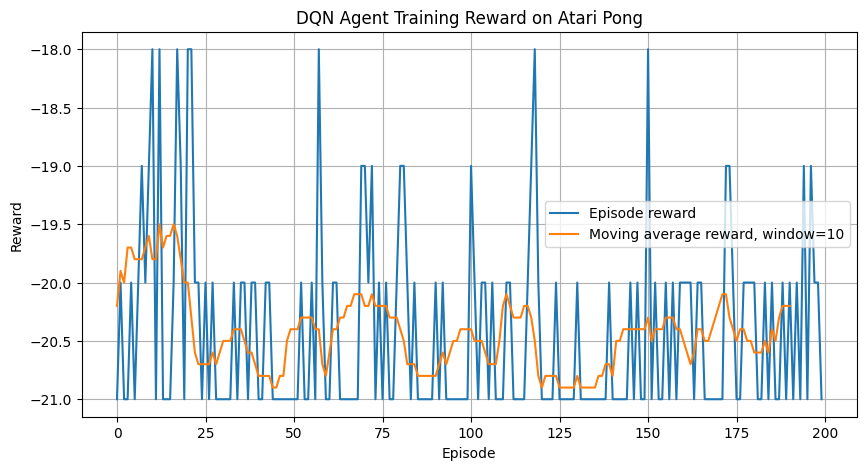

In [10]:
def moving_average(data, window=10):
    if len(data) < window:
        return data
    return np.convolve(data, np.ones(window) / window, mode="valid")


plt.figure(figsize=(10, 5))
plt.plot(episode_rewards, label="Episode reward")

ma = moving_average(episode_rewards, window=10)
plt.plot(
    range(len(ma)),
    ma,
    label="Moving average reward, window=10"
)

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("DQN Agent Training Reward on Atari Pong")
plt.legend()
plt.grid(True)
plt.show()